* **Setup**

In [2]:
import sys, os
current_directory = os.getcwd()
root_directory = os.path.abspath(os.path.join(current_directory, os.pardir))
sys.path.append(root_directory)

* **Import utils**

In [3]:
from pretrained.predictor import SingleKModel, MultiKModel, OneTestKModel
import metrics

2025-11-06 15:46:16.600148: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 15:46:16.703796: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 15:46:21.497727: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 15:46:37.640271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

* **Predict**

1- Using single K Model

In [4]:
kmodel = SingleKModel(kmer_size=3)
kmodel.load("../data/testset-full/k3/testset.csv", format="csv", type='kmer_file')
genboard = kmodel.predict()

Predicting: 100%|██████████| 58/58 [05:24<00:00,  5.60s/it]


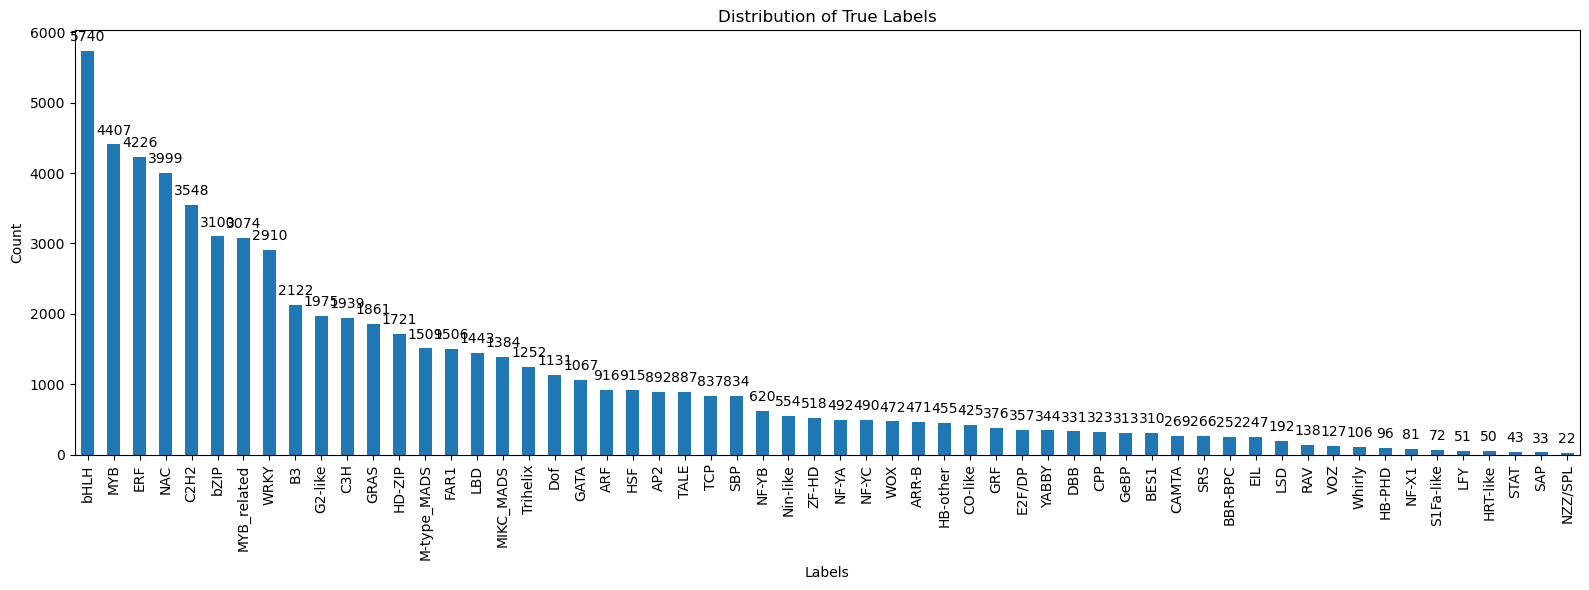

In [5]:
metrics.plot_testset(true_label_df_path="../data/testset-full/k3/true_labels.csv", class_mapping_df_path="../data/testset-full/k3/class_mapping.json")

In [22]:
#genboard.display()

<!--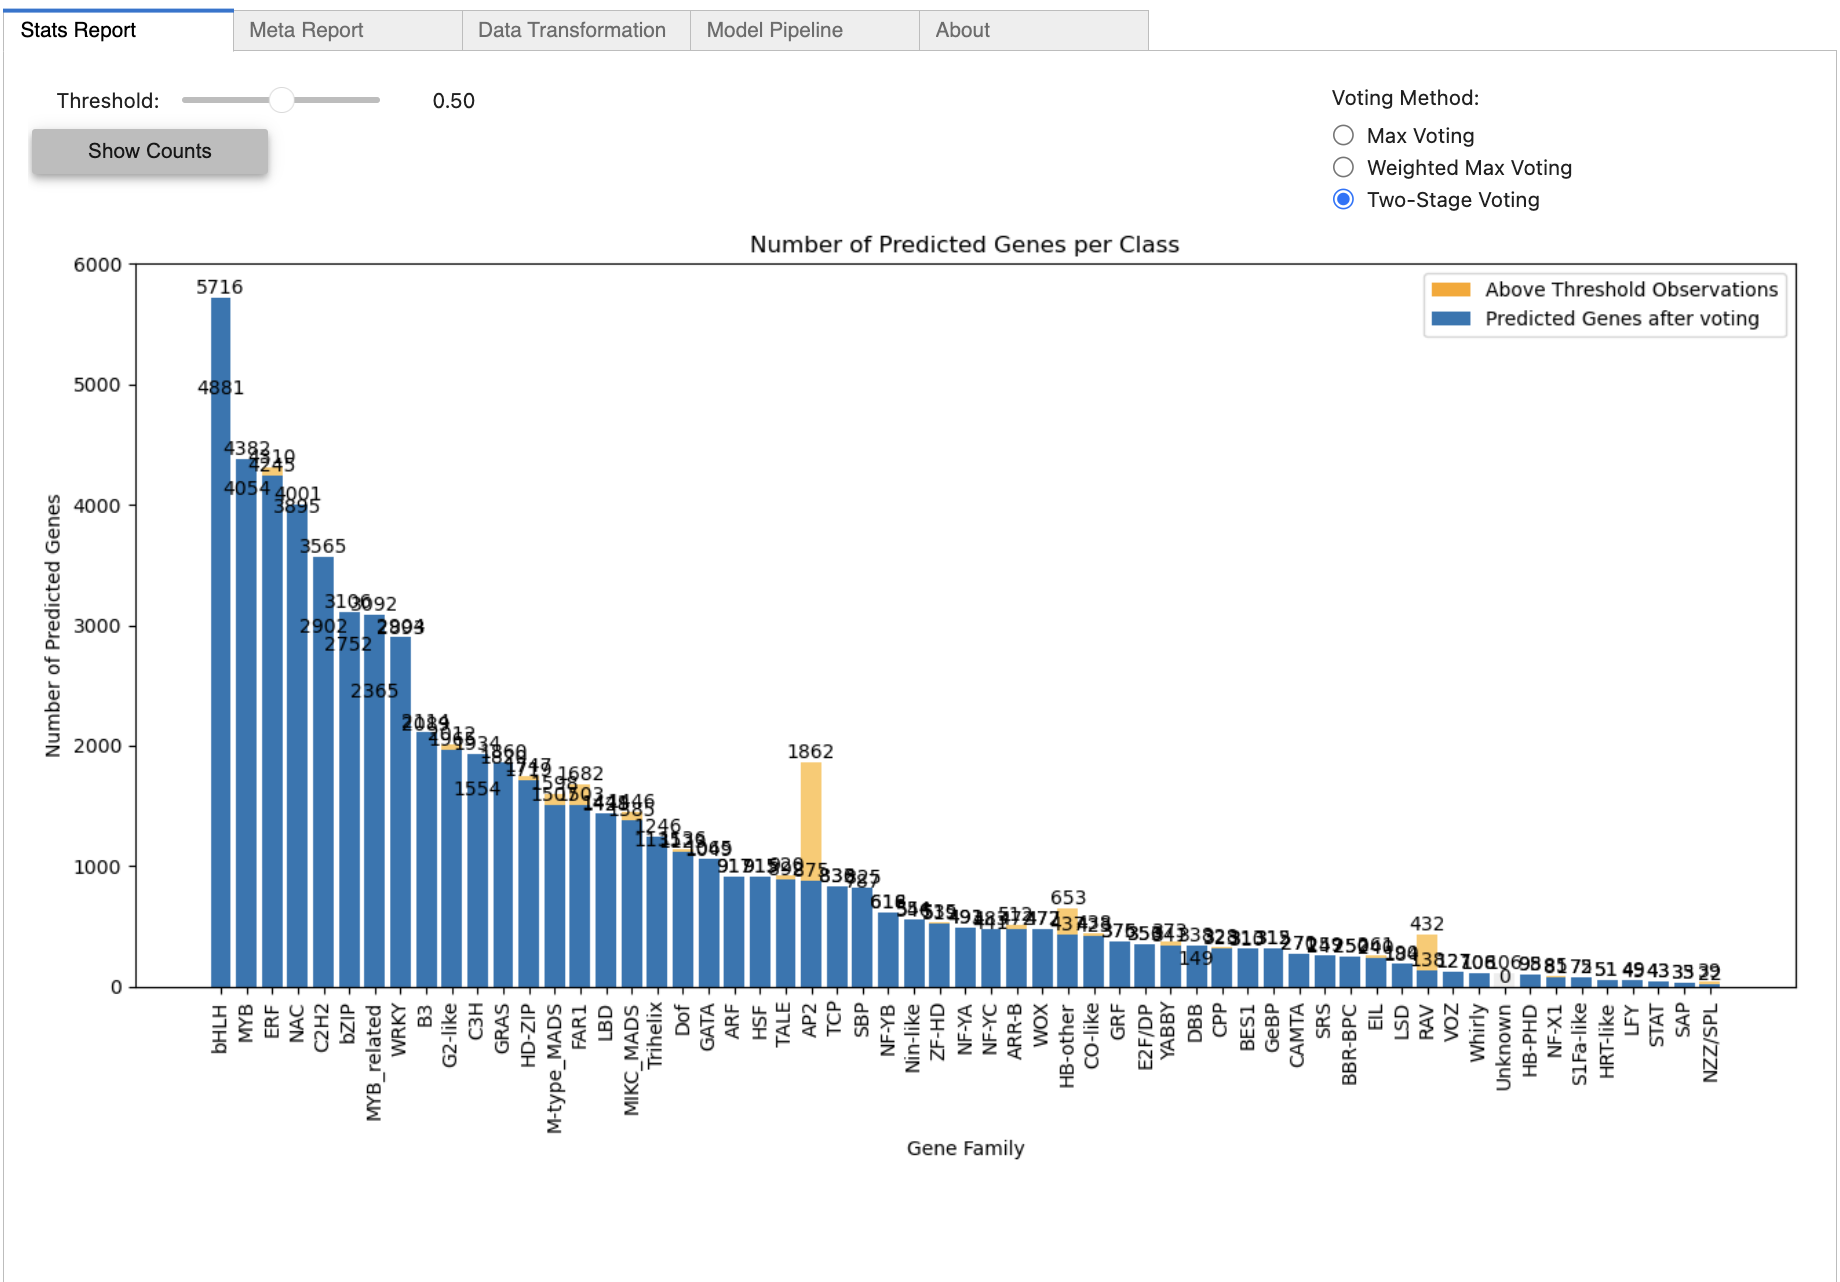

In [7]:
genboard.prediction.shape

(64091, 58)

* **Confusion report for validation**

In [8]:
import json
import pandas as pd

true_label = pd.read_csv('../data/testset-full/k3/true_labels.csv')['true_label'].values
with open('../data/testset-full/k3/class_mapping.json', 'r') as json_file:
    class_mapping = json.load(json_file)
# class_mapping['Unknown'] = 0

In [9]:
# genboard.show_eval_metric(
#     true_label=true_label,
#     class_mapping_rules=class_mapping,
#     voting_method="Two-Stage Voting",
#     voting_threshold=0.5,
#     binary_class_threshold=0.5,
#     components=['confusion_matrix', 'general_accuracy', 'accuracy_per_family'],
#     #metrics_storage_path="./metrics"
# )

In [10]:
# genboard.show_roc_curve(
#     true_label=true_label,
#     class_mapping_rules=class_mapping,
#     voting_method="Two-Stage Voting",#"Max Voting",# "Two-Stage Voting"
#     voting_threshold=0.5,
#     save_path="results/roc_curve_k3.png"
# )

genboard.compute_and_save_roc_per_family(
    true_label=true_label,
    class_mapping_rules=class_mapping,
    voting_method="Max Voting",#"Max Voting"
    voting_threshold=0.1,
    save_folder="results/maxvoting/k3"
)


✅ Saved ROC and metric data for k=3 → results/maxvoting/k3


In [12]:
genboard.compute_and_save_roc_per_family(
    true_label=true_label,
    class_mapping_rules=class_mapping,
    voting_method="Two-Stage Voting",#"Max Voting"
    voting_threshold=0.1,
    save_folder="results/2ndvoting/k3"
)

✅ Saved ROC and metric data for k=3 → results/2ndvoting/k3


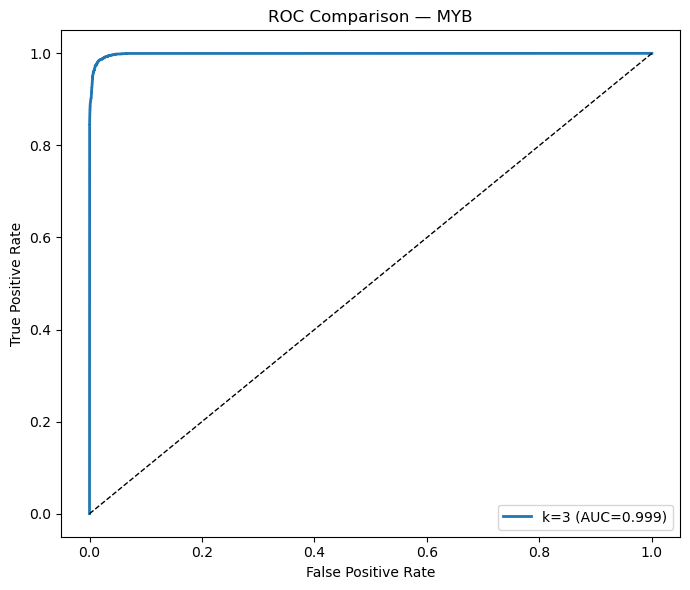

In [11]:
genboard.compare_roc_across_k(
    family_name="MYB",
    roc_folders=["results/maxvoting/k3",],# "results/k4", "results/k5"],
    save_path="results/maxvoting/compare_MYB.png"
)

In [13]:
genboard.two_stage_prediction

,AP2,ARF,ARR-B,B3,BBR-BPC,BES1,C2H2,C3H,CAMTA,CO-like,...,TCP,Trihelix,VOZ,WOX,WRKY,Whirly,YABBY,ZF-HD,bHLH,bZIP
0,2.327722e-38,0.0,0.000000e+00,6.873081e-37,5.837215e-33,1.041222e-34,2.628163e-16,6.399260e-29,3.241407e-20,1.553497e-25,...,0.000000e+00,0.0,0.0,0.000000e+00,2.157179e-17,0.000000e+00,1.122036e-26,2.057182e-21,7.570819e-19,0.0
1,1.646678e-38,0.0,0.000000e+00,6.135285e-37,8.999496e-33,1.427663e-34,4.003069e-16,1.871857e-28,2.968859e-20,2.379314e-25,...,0.000000e+00,0.0,0.0,0.000000e+00,2.670140e-17,0.000000e+00,2.016072e-26,3.005493e-21,2.350975e-18,0.0
2,0.000000e+00,0.0,0.000000e+00,2.187921e-37,5.822888e-35,5.146073e-36,9.814020e-18,5.027417e-30,2.395833e-20,2.992925e-25,...,0.000000e+00,0.0,0.0,0.000000e+00,3.254258e-18,0.000000e+00,5.075983e-28,4.825037e-22,2.237349e-20,0.0
3,0.000000e+00,0.0,0.000000e+00,4.168098e-37,3.796652e-34,1.746988e-35,3.355718e-17,2.617949e-29,2.123141e-20,3.613133e-25,...,0.000000e+00,0.0,0.0,0.000000e+00,4.475276e-18,0.000000e+00,3.074223e-27,1.385935e-21,7.616527e-20,0.0
4,1.324930e-37,0.0,0.000000e+00,2.684367e-37,1.242417e-30,1.826314e-33,8.926842e-15,6.434652e-28,1.518851e-19,5.126636e-26,...,0.000000e+00,0.0,0.0,2.209195e-37,9.763819e-18,0.000000e+00,5.644186e-26,1.583776e-21,1.170101e-18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64086,0.000000e+00,0.0,1.853438e-30,9.403266e-25,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.684631e-35,0.0,0.0,1.091153e-37,4.922179e-35,2.299578e-37,9.031541e-35,0.000000e+00,0.000000e+00,0.0
64087,0.000000e+00,0.0,3.786647e-32,3.233125e-25,0.000000e+00,3.145810e-32,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.673545e-34,0.0,0.0,3.981768e-36,0.000000e+00,1.620117e-37,5.054554e-36,0.000000e+00,0.000000e+00,0.0
64088,0.000000e+00,0.0,4.676966e-35,6.331639e-28,0.000000e+00,8.419341e-37,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.0,0.0,8.592372e-38,3.559444e-36,0.000000e+00,1.537084e-35,0.000000e+00,0.000000e+00,0.0
64089,0.000000e+00,0.0,0.000000e+00,2.283922e-29,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.934933e-37,0.000000e+00,0.000000e+00,0.0


In [19]:
import pandas as pd
import os

df = genboard.two_stage_prediction.copy()
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df["predicted_class"] = df[numeric_cols].idxmax(axis=1)
df["max_probability"] = df[numeric_cols].max(axis=1)

voting_threshold = 0.5
df["filtered_prediction"] = df.apply(
    lambda x: x["predicted_class"] if x["max_probability"] >= voting_threshold else "Unknown",
    axis=1
)
output = df[["predicted_class", "max_probability", "filtered_prediction"]]
output_path = "./results/analysis-by-species/predicted_classes_threshold.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output.to_csv(output_path, index_label="sequence_id")


output.head(10)

,predicted_class,max_probability,filtered_prediction
0,Dof,1.000000,Dof
1,Dof,1.000000,Dof
2,Dof,1.000000,Dof
3,Dof,1.000000,Dof
4,Dof,0.999995,Dof
5,Dof,1.000000,Dof
6,Dof,0.999998,Dof
7,Dof,1.000000,Dof
8,Dof,1.000000,Dof
9,Dof,1.000000,Dof


In [20]:
lowest_row = df.loc[df["max_probability"].idxmin()]
print(lowest_row)


AP2                    0.000289
ARF                    0.000906
ARR-B                  0.000002
B3                     0.084663
BBR-BPC                0.000065
                         ...   
bHLH                   0.132504
bZIP                   0.080563
predicted_class            bHLH
max_probability        0.132504
filtered_prediction     Unknown
Name: 28365, Length: 61, dtype: object
